# Bedrock Latency Tests

> :DISCLAIMER: *THIS IS FOR DEMONSTRATION PURPOSES ONLY AND NOT TO BE REUSED. NO WARRANTY PROVIDED OF ANY KIND*

Code to run latency tests on Bedrock

Find model ID Details Here:
https://docs.aws.amazon.com/bedrock/latest/userguide/model-ids.html


## How to Read the graph output

Taken from: https://builtin.com/data-science/boxplot

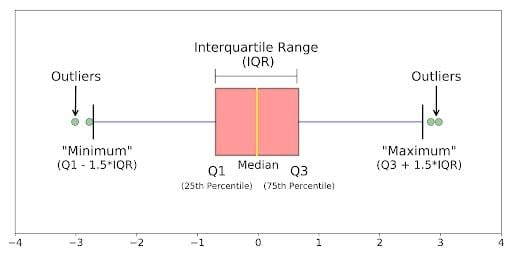


## Full Latency Test Suite

Time to First Token (TTFT): 0.461 seconds
Time to First Token (TTFT): 0.470 seconds
Time to First Token (TTFT): 0.438 seconds
Time to First Token (TTFT): 0.489 seconds
Time to First Token (TTFT): 0.463 seconds
Time to First Token (TTFT): 0.538 seconds
Time to First Token (TTFT): 0.517 seconds
Time to First Token (TTFT): 0.523 seconds
Time to First Token (TTFT): 0.516 seconds
Time to First Token (TTFT): 0.498 seconds


/var/folders/r3/fsxlqp1s4s99m07h4_nxq1vc0000gr/T/ipykernel_40601/3130383370.py:255: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



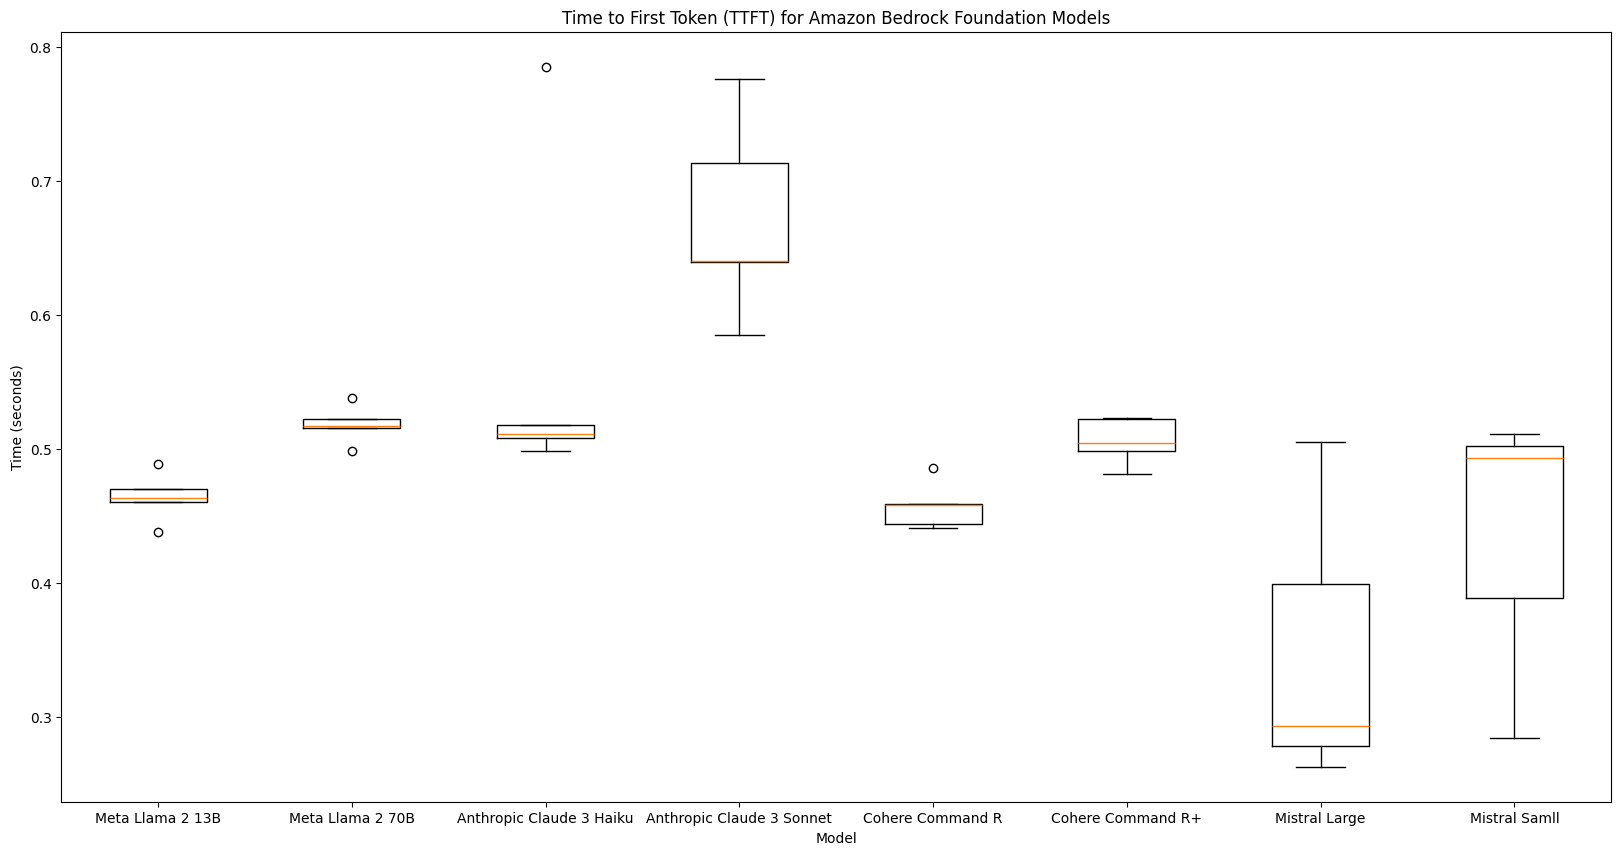

In [41]:
import boto3
import json
import time
import matplotlib.pyplot as plt

##################
# Connect to Amazon Bedrock and prompt claude 3
##################
import boto3
import json

# Create a Boto3 session using the 'mlprofile' profile
session = boto3.Session(profile_name='mlprofile')

# Create a Bedrock Runtime client using the session
bedrock_client = session.client('bedrock-runtime', region_name='us-east-1')

##################
# TEST SETUP (You can change these variables)
##################

trials = 5 # the number of trials per model. Setting to '3' will fire 3 cycles of prompting each model and timing the response

##################
# Model ID, Variable Init
##################

# Set the model IDs
haiku_model_id = "anthropic.claude-3-haiku-20240307-v1:0"
sonnet_model_id = "anthropic.claude-3-sonnet-20240229-v1:0"
llama2_13b_model_id = 'meta.llama2-13b-chat-v1'
llama2_70b_model_id = 'meta.llama2-70b-chat-v1'
command_r_model_id = "cohere.command-r-v1:0"
command_r_plus_model_id = "cohere.command-r-plus-v1:0"
mistral_large_model_id = "mistral.mistral-large-2402-v1:0"
mistral_small_model_id = "mistral.mistral-small-2402-v1:0"

# Lists to store TTFT values
haiku_ttft_values = []
sonnet_ttft_values = []
llama2_13b_ttft_values = []
llama2_70b_ttft_values = []
command_r_ttft_values = []
command_r_plus_ttft_values = []
mistral_large_ttft_values = []
mistral_small_ttft_values = []

##################
# Prompts
##################

# Define the prompt
prompt = "Hello, can you write a short poem about programming?"

########
# Claude
########

# Format the request payload
claude_request = {
    "anthropic_version": "bedrock-2023-05-31",
    "max_tokens": 1024,
    "messages": [
        {
            "role": "user",
            "content": [{"type": "text", "text": prompt}],
        }
    ],
}

########
# LLaMa
########

# Format the request payload
llama_request = {
    "prompt": f"<s>[INST] {prompt} [/INST]",
    "temperature": 0.5,
    "top_p": 0.9,
}

########
# Command R
########

# Format the request payload
command_request = {
    "message": prompt,
    "max_tokens": 512,
    "temperature": 0.6,
    "p": 0.5,
    "k": 250
}

########
# Mistral
########

# Format the request payload
mistral_request = {
    "prompt": f"<s>[INST] {prompt} [/INST]",
    "max_tokens": 1024,
    "temperature": 0.5,
    "top_p": 0.9,
}

####################################
# Latency Tests
####################################

########
# Claude
########

# Run 3 calls to Anthropic Claude 3 Haiku and measure TTFT
for _ in range(trials):
    start_time = time.time()
    streaming_response = bedrock_client.invoke_model_with_response_stream(
        modelId=haiku_model_id, body=json.dumps(claude_request)
    )

    first_token_received = False
    for event in streaming_response["body"]:
        chunk = json.loads(event["chunk"]["bytes"])
        if chunk["type"] == "content_block_delta":
            if not first_token_received:
                ttft = time.time() - start_time
                first_token_received = True
                haiku_ttft_values.append(ttft)
                print(f"Time to First Token (TTFT) Claude 3 Haiku : {ttft:.3f} seconds")


# Run 3 calls to Anthropic Claude 3 Sonnet and measure TTFT
for _ in range(trials):
    start_time = time.time()
    streaming_response = bedrock_client.invoke_model_with_response_stream(
        modelId=sonnet_model_id, body=json.dumps(claude_request)
    )

    first_token_received = False
    for event in streaming_response["body"]:
        chunk = json.loads(event["chunk"]["bytes"])
        if chunk["type"] == "content_block_delta":
            if not first_token_received:
                ttft = time.time() - start_time
                first_token_received = True
                sonnet_ttft_values.append(ttft)
                print(f"Time to First Token (TTFT) Claude 3 Sonnet : {ttft:.3f} seconds")

########
# LLaMa
########

# Run 3 prompt requests and measure TTFT
for _ in range(trials):
    start_time = time.time()
    streaming_response = bedrock_client.invoke_model_with_response_stream(
        modelId=llama2_13b_model_id, body=json.dumps(llama_request)
    )

    first_token_received = False
    for event in streaming_response["body"]:
        chunk = json.loads(event["chunk"]["bytes"])
        if not first_token_received:
            ttft = time.time() - start_time
            first_token_received = True
            llama2_13b_ttft_values.append(ttft)
            print(f"Time to First Token (TTFT) LLaMa 2 13B : {ttft:.3f} seconds")

# Run 3 prompt requests and measure TTFT
for _ in range(trials):
    start_time = time.time()
    streaming_response = bedrock_client.invoke_model_with_response_stream(
        modelId=llama2_70b_model_id, body=json.dumps(llama_request)
    )

    first_token_received = False
    for event in streaming_response["body"]:
        chunk = json.loads(event["chunk"]["bytes"])
        if not first_token_received:
            ttft = time.time() - start_time
            first_token_received = True
            llama2_70b_ttft_values.append(ttft)
            print(f"Time to First Token (TTFT) LLaMa 2 70B : {ttft:.3f} seconds")

########
# Command R
########

# Run 3 calls to Cohere Command R and measure TTFT
for _ in range(trials):
    start_time = time.time()
    streaming_response = bedrock_client.invoke_model_with_response_stream(
        modelId=command_r_model_id, body=json.dumps(command_request)
    )

    first_token_received = False
    for event in streaming_response["body"]:
        chunk = json.loads(event["chunk"]["bytes"])
        if not first_token_received:
            ttft = time.time() - start_time
            first_token_received = True
            command_r_ttft_values.append(ttft)
            print(f"Time to First Token (TTFT) Command R : {ttft:.3f} seconds")

# Run 3 calls to Cohere Command R+ and measure TTFT
for _ in range(trials):
    start_time = time.time()
    streaming_response = bedrock_client.invoke_model_with_response_stream(
        modelId=command_r_plus_model_id, body=json.dumps(command_request)
    )

    first_token_received = False
    for event in streaming_response["body"]:
        chunk = json.loads(event["chunk"]["bytes"])
        if not first_token_received:
            ttft = time.time() - start_time
            first_token_received = True
            command_r_plus_ttft_values.append(ttft)
            print(f"Time to First Token (TTFT) Command R+ : {ttft:.3f} seconds")

########
# Mistral
########

# Run 3 calls to mistral.mistral-large-2402-v1:0 and measure TTFT
for _ in range(3):
    start_time = time.time()
    streaming_response = bedrock_client.invoke_model_with_response_stream(
        modelId=mistral_large_model_id, body=json.dumps(mistral_request)
    )

    first_token_received = False
    for event in streaming_response["body"]:
        chunk = json.loads(event["chunk"]["bytes"])
        if not first_token_received:
            ttft = time.time() - start_time
            first_token_received = True
            mistral_large_ttft_values.append(ttft)
            print(f"Time to First Token (TTFT) Mistral Large : {ttft:.3f} seconds")

# Run 3 calls to mistral.mistral-small-2402-v1:0 and measure TTFT
for _ in range(3):
    start_time = time.time()
    streaming_response = bedrock_client.invoke_model_with_response_stream(
        modelId=mistral_small_model_id, body=json.dumps(mistral_request)
    )

    first_token_received = False
    for event in streaming_response["body"]:
        chunk = json.loads(event["chunk"]["bytes"])
        if not first_token_received:
            ttft = time.time() - start_time
            first_token_received = True
            mistral_small_ttft_values.append(ttft)
            print(f"Time to First Token (TTFT) Mistral Small : {ttft:.3f} seconds")
            
plt.figure(figsize=(20, 10))
plt.boxplot([llama2_13b_ttft_values, llama2_70b_ttft_values, haiku_ttft_values, sonnet_ttft_values, command_r_ttft_values, command_r_plus_ttft_values, mistral_large_ttft_values, mistral_small_ttft_values],
             labels=["Meta Llama 2 13B", "Meta Llama 2 70B","Anthropic Claude 3 Haiku", "Anthropic Claude 3 Sonnet", "Cohere Command R", "Cohere Command R+", "Mistral Large", "Mistral Samll",])
plt.title("Time to First Token (TTFT) for Amazon Bedrock Foundation Models")
plt.xlabel("Model")
plt.ylabel("Time (seconds)")
plt.show()

## Amazon Titan Models

/var/folders/r3/fsxlqp1s4s99m07h4_nxq1vc0000gr/T/ipykernel_40601/131022049.py:59: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



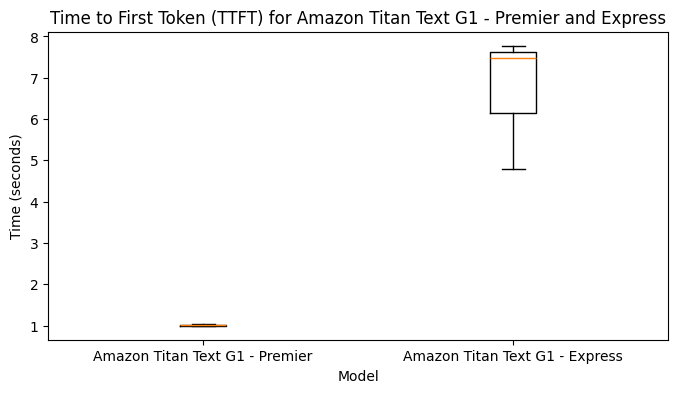

In [36]:
import boto3
import json
import time
import matplotlib.pyplot as plt

# Set the model IDs
titan_premier_model_id = "amazon.titan-text-premier-v1:0"
titan_express_model_id = "amazon.titan-text-express-v1"

# Define the prompt
prompt = "Hello, can you write a short poem about programming?"

# Format the request payload
request = {
    "inputText": prompt,
    "textGenerationConfig": {
        "maxTokenCount": 1024,
        "temperature": 0.5,
        "topP": 0.9,
    }
}

# Lists to store TTFT values
titan_premier_ttft_values = []
titan_express_ttft_values = []

# Run 3 calls to Amazon Titan Text G1 - Premier and measure TTFT
for _ in range(3):
    start_time = time.time()
    streaming_response = bedrock_client.invoke_model_with_response_stream(
        modelId=titan_premier_model_id, body=json.dumps(request)
    )

    first_token_received = False
    for event in streaming_response["body"]:
        chunk = json.loads(event["chunk"]["bytes"])
        if not first_token_received:
            ttft = time.time() - start_time
            first_token_received = True
            titan_premier_ttft_values.append(ttft)

# Run 3 calls to Amazon Titan Text G1 - Express and measure TTFT
for _ in range(3):
    start_time = time.time()
    streaming_response = bedrock_client.invoke_model_with_response_stream(
        modelId=titan_express_model_id, body=json.dumps(request)
    )

    first_token_received = False
    for event in streaming_response["body"]:
        chunk = json.loads(event["chunk"]["bytes"])
        if not first_token_received:
            ttft = time.time() - start_time
            first_token_received = True
            titan_express_ttft_values.append(ttft)

# Draw a box plot of TTFT values for both models
plt.figure(figsize=(8, 4))
plt.boxplot([titan_premier_ttft_values, titan_express_ttft_values], labels=["Amazon Titan Text G1 - Premier", "Amazon Titan Text G1 - Express"])
plt.title("Time to First Token (TTFT) for Amazon Titan Text G1 - Premier and Express")
plt.xlabel("Model")
plt.ylabel("Time (seconds)")
plt.show()
